# Product Clustering — Market Segmentation

## Business Problem

Sephora's catalog spans thousands of products across dozens of brands, but the platform's own category labels (Makeup, Skincare, Fragrance, ...) say nothing about how a product actually *performs* in the market. A cheap, highly-loved product and an expensive, under-the-radar product can sit in the same category and look nothing alike from a business perspective. The same is true one level up: two brands can have similar catalog sizes yet occupy completely different strategic positions — one a mainstream volume driver, the other a niche brand charging a premium without the ratings to back it up.

This notebook uses **unsupervised learning (K-Means clustering)** to answer two related questions:

1. **Product level:** Can individual products be grouped into meaningful market segments based on price, rating, and customer engagement (reviews, loves)?
2. **Brand level:** Can brands be grouped into strategic positioning tiers based on their aggregate catalog performance (average price, average rating, total engagement, catalog size)?

Unlike Notebook 02 (classification), there is no labeled target here — the goal is to let the structure in the data reveal natural groupings, then interpret and name those groupings in business terms.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

## Load Dataset

This notebook only needs the **products** dataset — clustering is performed on catalog-level attributes (price, rating, reviews, loves), not on individual review text.

In [2]:
products = pd.read_csv('data/processed/cleaned_product_info.csv')
products.shape

(7305, 20)

In [3]:
products.columns

Index(['product_id', 'product_name', 'brand_id', 'brand_name', 'loves_count',
       'rating', 'reviews', 'size', 'ingredients', 'price_usd',
       'limited_edition', 'new', 'online_only', 'out_of_stock',
       'sephora_exclusive', 'highlights', 'primary_category',
       'secondary_category', 'tertiary_category', 'child_count'],
      dtype='object')

In [4]:
products.dtypes

product_id             object
product_name           object
brand_id                int64
brand_name             object
loves_count             int64
rating                float64
reviews               float64
size                   object
ingredients            object
price_usd             float64
limited_edition          bool
new                      bool
online_only              bool
out_of_stock             bool
sephora_exclusive        bool
highlights             object
primary_category       object
secondary_category     object
tertiary_category      object
child_count             int64
dtype: object

In [5]:
products[['product_id','product_name','brand_name','price_usd','rating','reviews','loves_count','primary_category']].head()

,product_id,product_name,brand_name,price_usd,rating,reviews,loves_count,primary_category
0,P473671,Fragrance Discovery Set,19-69,35.0,3.64,11.0,6320,Fragrance
1,P473668,La Habana Eau de Parfum,19-69,195.0,4.15,13.0,3827,Fragrance
2,P473662,Rainbow Bar Eau de Parfum,19-69,195.0,4.25,16.0,3253,Fragrance
3,P473660,Kasbah Eau de Parfum,19-69,195.0,4.48,21.0,3018,Fragrance
4,P473658,Purple Haze Eau de Parfum,19-69,195.0,3.23,13.0,2691,Fragrance


## Data Cleaning & Preprocessing

The core numeric features needed for clustering are `price_usd`, `rating`, `reviews`, and `loves_count`. These were already cleaned in Notebook 01, but we double check for missing values before clustering, since K-Means cannot handle NaN.

In [6]:
# All columns are numerical
cluster_feats = ['price_usd', 'rating', 'reviews', 'loves_count']
products[cluster_feats].isna().sum()

price_usd      0
rating         0
reviews        0
loves_count    0
dtype: int64

In [7]:
products_clean = products.dropna(subset=cluster_feats).copy()
print(f"Products available for clustering: {len(products_clean)} (out of {len(products)})")

Products available for clustering: 7305 (out of 7305)


# Part 1 — Product-Level Segmentation

## Feature Engineering: Handling Skew

Following with findings from notebook 01. `price_usd`, `reviews`, and `loves_count` are all **strongly right-skewed**. If those are put in the KMeans, the distance calculations will be influenced, therefore inaccurate.


To fix this, a **log1p transform** is applied to the three skewed columns before scaling. `rating` is already reasonably well-behaved (bounded 1–5) so it's left as-is.

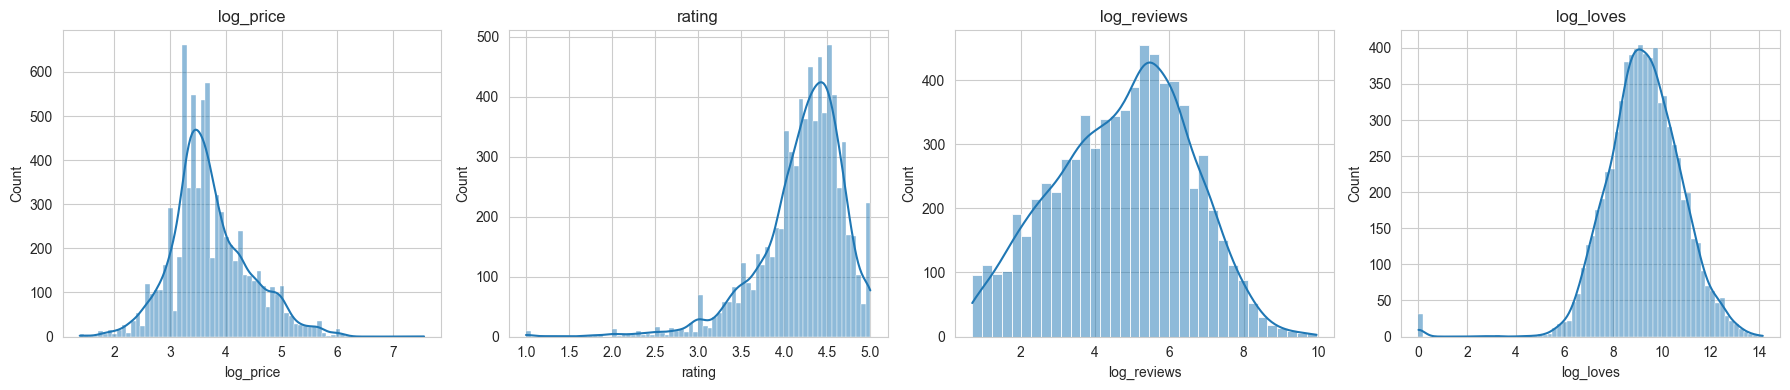

In [8]:
products_clean['log_price'] = np.log1p(products_clean['price_usd'])
products_clean['log_reviews'] = np.log1p(products_clean['reviews'])
products_clean['log_loves'] = np.log1p(products_clean['loves_count'])

model_feats = ['log_price', 'rating', 'log_reviews', 'log_loves']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, model_feats):
    sns.histplot(products_clean[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

### Scaling
Since KMeans relies on distance, I will use sklearn `StandardScaler` so each feature has mean=0, std=1.

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(products_clean[model_feats])
X_scaled.shape

(7305, 4)

### Choosing K: Elbow Method + Silhouette Score
Subplot showing both

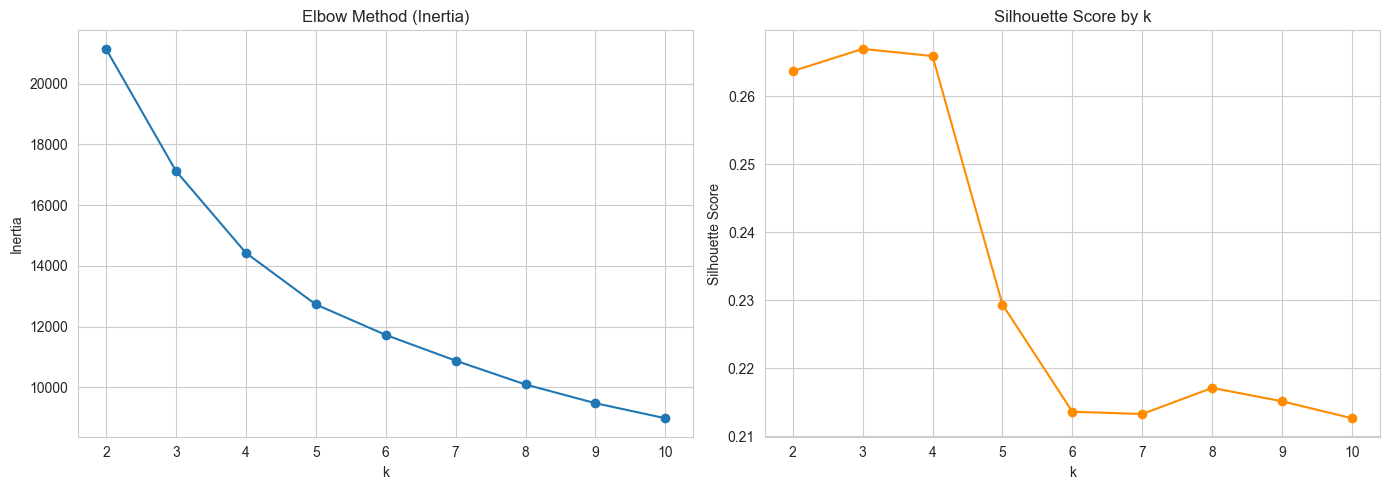

,k,inertia,silhouette
0,2,21146.844744,0.263719
1,3,17126.019782,0.266994
2,4,14428.752771,0.265941
3,5,12728.651675,0.229373
4,6,11724.609177,0.213595
5,7,10875.822402,0.213262
6,8,10090.908708,0.217102
7,9,9474.654329,0.215131
8,10,8978.628435,0.212637


In [10]:
k_range = range(2, 11)
inertias, sil_scores = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(k_range), sil_scores, marker='o', color='darkorange')
axes[1].set_title('Silhouette Score by k')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

pd.DataFrame({'k': list(k_range), 'inertia': inertias, 'silhouette': sil_scores})

### Observation
k=4 is chosen considering elbow starts to flatten and silhouette score peaks there too.

In [11]:
# how many rows are assigned to each cluster
kmeans_products = KMeans(n_clusters=4, random_state=42, n_init=10)
products_clean['cluster'] = kmeans_products.fit_predict(X_scaled)
products_clean['cluster'].value_counts().sort_index()

cluster
0    2018
1    2892
2     957
3    1438
Name: count, dtype: int64

### Visualising with PCA
`X_scaled` has 4 columns, so KMeans clusters in 4D, PCA can compress it for 2D, which can be shown.

Explained variance: 71.5%


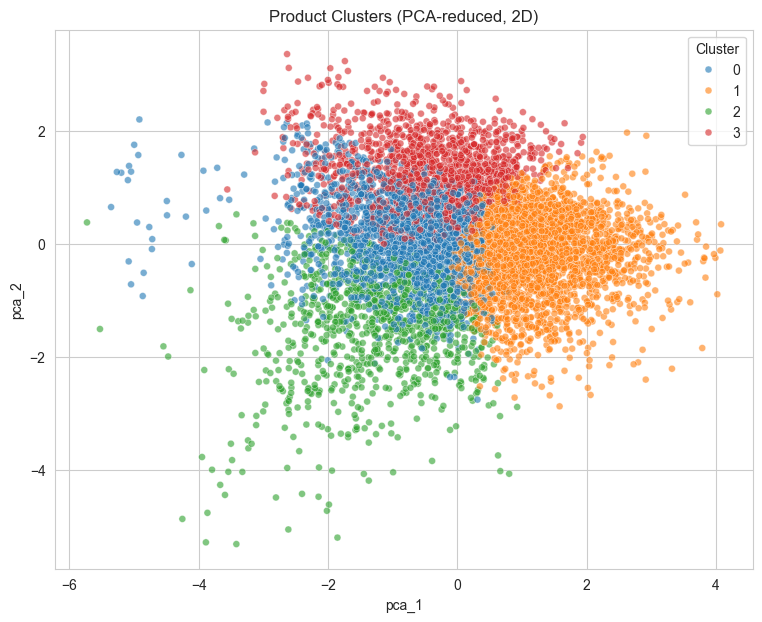

In [12]:
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_scaled)
products_clean['pca_1'] = pca_coords[:, 0]
products_clean['pca_2'] = pca_coords[:, 1]

print(f"Explained variance: {pca.explained_variance_ratio_.sum():.1%}")

plt.figure(figsize=(9, 7))
sns.scatterplot(data=products_clean, x='pca_1', y='pca_2', hue='cluster', palette='tab10', alpha=0.6, s=25)
plt.title('Product Clusters (PCA-reduced, 2D)')
plt.legend(title='Cluster')
plt.show()

### Profiling the clusters


In [13]:
cluster_profile = products_clean.groupby('cluster')[['price_usd', 'rating', 'reviews', 'loves_count']].mean().round(2)
cluster_profile['n_products'] = products_clean['cluster'].value_counts().sort_index()
cluster_profile

,price_usd,rating,reviews,loves_count,n_products
cluster,,,,,
0,33.65,4.46,71.71,5886.11,2018
1,35.12,4.26,956.08,65853.79,2892
2,39.93,3.30,45.82,7407.03,957
3,125.38,4.36,228.72,10832.81,1438


Mean of price_usd, rating, reviews, loves_count per cluster, plus the row count per cluster.

In [14]:
for c in sorted(products_clean['cluster'].unique()):
    top_cats = products_clean.loc[products_clean['cluster'] == c, 'primary_category'].value_counts(normalize=True).head(3)
    print(f"Cluster {c} — top categories: {dict((top_cats * 100).round(1))}")

Cluster 0 — top categories: {'Hair': np.float64(26.6), 'Makeup': np.float64(23.3), 'Skincare': np.float64(21.8)}
Cluster 1 — top categories: {'Makeup': np.float64(46.1), 'Skincare': np.float64(28.6), 'Hair': np.float64(15.2)}
Cluster 2 — top categories: {'Makeup': np.float64(31.9), 'Hair': np.float64(20.9), 'Skincare': np.float64(20.3)}
Cluster 3 — top categories: {'Fragrance': np.float64(43.4), 'Skincare': np.float64(37.5), 'Hair': np.float64(10.0)}


Top categories per cluster shown down as a df

In [15]:
rows = []
for c in sorted(products_clean['cluster'].unique()):
    top_cats = (
        products_clean.loc[products_clean['cluster'] == c, 'primary_category']
        .value_counts(normalize=True)
        .head(3) * 100
    ).round(1)

    row = {'cluster': c}
    for rank, (cat, pct) in enumerate(top_cats.items(), start=1):
        row[f'top_{rank}_category'] = cat
        row[f'top_{rank}_%'] = pct
    rows.append(row)

top_categories_df = pd.DataFrame(rows).set_index('cluster')
top_categories_df

,top_1_category,top_1_%,top_2_category,top_2_%,top_3_category,top_3_%
cluster,,,,,,
0,Hair,26.6,Makeup,23.3,Skincare,21.8
1,Makeup,46.1,Skincare,28.6,Hair,15.2
2,Makeup,31.9,Hair,20.9,Skincare,20.3
3,Fragrance,43.4,Skincare,37.5,Hair,10.0


In [16]:
product_segmentation = pd.merge(cluster_profile, top_categories_df, on='cluster')
product_segmentation

,price_usd,rating,reviews,loves_count,n_products,top_1_category,top_1_%,top_2_category,top_2_%,top_3_category,top_3_%
cluster,,,,,,,,,,,
0,33.65,4.46,71.71,5886.11,2018,Hair,26.6,Makeup,23.3,Skincare,21.8
1,35.12,4.26,956.08,65853.79,2892,Makeup,46.1,Skincare,28.6,Hair,15.2
2,39.93,3.30,45.82,7407.03,957,Makeup,31.9,Hair,20.9,Skincare,20.3
3,125.38,4.36,228.72,10832.81,1438,Fragrance,43.4,Skincare,37.5,Hair,10.0


## Conclusions Part 1 — Product-Level Segmentation

Cluster 0:<br>
- lowest avg price
- highest rating
May suggest that those are 'budget gems' or known 'stable' evryday use products. Top categories are Hair, Makeup and Skincare.
<br><br>
Cluster 1:<br>
- price slightly higher
- rating avg slightly lower
- reviews avg count highest from all
Reviews count and loves_count tell us that this cluster represents the trendy products. The price is slightly up considering cluster 0 which keeps the products in the lower-to-medium price range. Top categories are Makeup, Skincare, Hair. Knowing that those products have biggest love_count business may consider marketing campaign with those products, or even checking if customers remember that they added such products to their favourite - can be done with custom newsletter or app notification.
<br><br>
Cluster 2:<br>
- price higher than two previous clusters
- lowest rating
- lowest review count
- love_counts higher than with cluster 0
This cluster should be taken into consideration, to improve the business. Those products may represent the "new products" which are not yet met the targeted audience, with customers engaged enough to save it to loved products but not eager to purchase considering higher price and lover rating.
<br><br>
Cluster 3:<br>
- highest avg price
- second best rating
- second best reviews count
This cluster' first category is Fragrance, which explains the higher price, Skincare and Hair are the remaining categories. This cluster represents top shelf, luxury products which also is shown in the rating. Business may consider that with the second best love_count customers are interested in those products and knowing that rating is good, potential customers may make purchase if products get discounted.

# Part 2 — Brand-Level Segmentation

Product-level clustering treats every product independently. But Sephora also needs to understand **brands** as strategic units, which brands are:
- mainstream powerhouses
- small-but-beloved niche players
- premium-positioned but not yet trusted

## Business Question

Can brands be grouped into meaningful positioning tiers based on their aggregate catalog performance?

### Feature Engineering: Aggregating to Brand Level

In [18]:
brand_df = products.groupby('brand_name').agg(
    n_products=('product_id', 'count'),
    avg_price=('price_usd', 'mean'),
    avg_rating=('rating', 'mean'),
    total_reviews=('reviews', 'sum'),
    total_loves=('loves_count', 'sum'),
).reset_index()

print(f"Total brands: {len(brand_df)}")

# Excluding small brands (up to 4 products) since they produce noise
brand_df = brand_df[brand_df['n_products'] >= 5].copy()
print(f"Brands with >= 5 products (used for clustering): {len(brand_df)}")
brand_df

Total brands: 294
Brands with >= 5 products (used for clustering): 253


,brand_name,n_products,avg_price,avg_rating,total_reviews,total_loves
0,19-69,14,112.857143,3.720714,162.0,31916
2,ABBOTT,13,54.076923,4.377692,172.0,20676
3,AERIN,21,113.809524,3.959048,1316.0,130437
4,ALTERNA Haircare,43,36.395349,4.288837,8670.0,310242
5,Acqua di Parma,13,132.461538,4.184615,270.0,27685
...,...,...,...,...,...,...
289,maude,12,32.666667,4.740000,1194.0,64630
290,rms beauty,10,37.700000,4.349000,3245.0,284051
291,shu uemura,43,54.930233,4.405116,5978.0,159120
292,stila,9,28.777778,4.153333,19197.0,1309556


`log1p()` compresses the long right tail (a few mega-brands dominate raw reviews/loves/price/n_products), pulling means and medians closer together so no single feature dominates distance calcs once StandardScaler is applied.

In [21]:
brand_df['log_price'] = np.log1p(brand_df['avg_price'])
brand_df['log_reviews'] = np.log1p(brand_df['total_reviews'])
brand_df['log_loves'] = np.log1p(brand_df['total_loves'])
brand_df['log_n_products'] = np.log1p(brand_df['n_products'])

brand_feats = ['log_price', 'avg_rating', 'log_reviews', 'log_loves', 'log_n_products']
brand_df[brand_feats].describe().round(2)

,log_price,avg_rating,log_reviews,log_loves,log_n_products
count,253.00,253.00,253.00,253.00,253.00
mean,3.86,4.24,8.46,12.66,3.11
std,0.57,0.24,1.58,1.54,0.71
min,2.52,3.27,4.17,9.02,1.79
25%,3.43,4.12,7.31,11.69,2.56
50%,3.79,4.26,8.54,12.65,3.04
75%,4.24,4.41,9.69,13.81,3.64
max,5.75,4.86,11.68,16.31,5.77


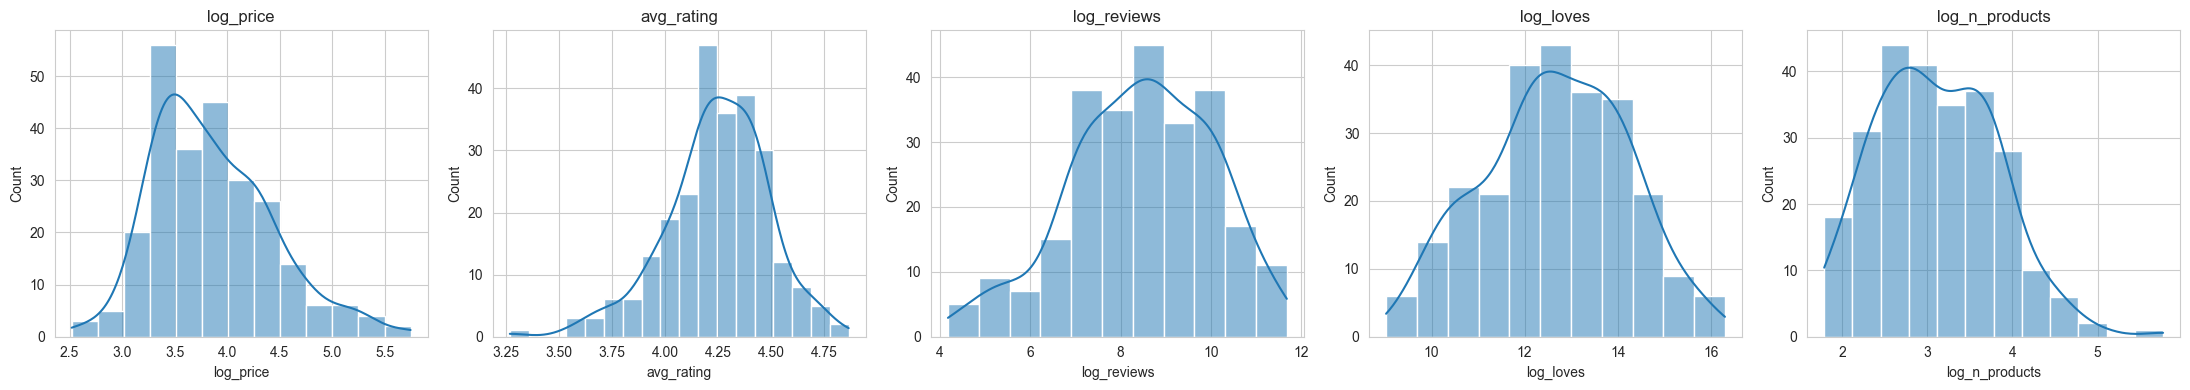

In [22]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, col in zip(axes, brand_feats):
    sns.histplot(brand_df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

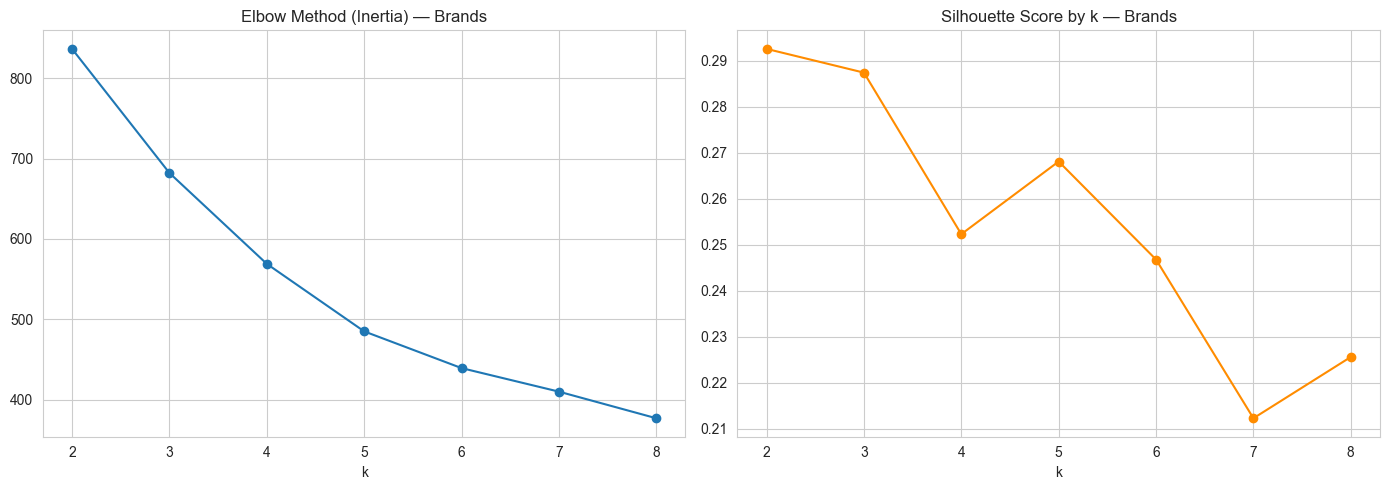

,k,inertia,silhouette
0,2,836.458419,0.292599
1,3,682.046011,0.287433
2,4,568.953536,0.252318
3,5,484.938399,0.268116
4,6,439.237237,0.246803
5,7,409.942560,0.212302
6,8,376.828776,0.225623


In [23]:
brand_scaler = StandardScaler()
X_brand_scaled = brand_scaler.fit_transform(brand_df[brand_feats])

k_range = range(2, 9)
inertias, sil_scores = [], []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_brand_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_brand_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_title('Elbow Method (Inertia) — Brands')
axes[0].set_xlabel('k')

axes[1].plot(list(k_range), sil_scores, marker='o', color='darkorange')
axes[1].set_title('Silhouette Score by k — Brands')
axes[1].set_xlabel('k')
plt.tight_layout()
plt.show()

pd.DataFrame({'k': list(k_range), 'inertia': inertias, 'silhouette': sil_scores})

k=3 is best considering both elbow and Silhouette score

In [25]:
# how many rows are assigned to each cluster
kmeans_brands = KMeans(n_clusters=3, random_state=42, n_init=10)
brand_df['cluster'] = kmeans_brands.fit_predict(X_brand_scaled)
brand_df['cluster'].value_counts().sort_index()

cluster
0    125
1     64
2     64
Name: count, dtype: int64

### Visualising Brand Clusters
Just like with products PCS is used to make a plot.

Explained variance: 72.5%


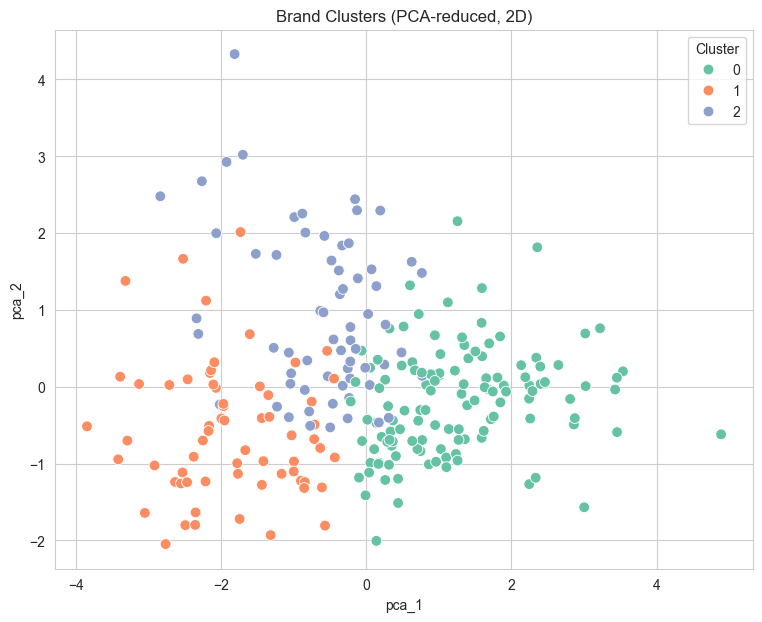

In [26]:
pca_b = PCA(n_components=2, random_state=42)
brand_pca = pca_b.fit_transform(X_brand_scaled)
brand_df['pca_1'] = brand_pca[:, 0]
brand_df['pca_2'] = brand_pca[:, 1]

print(f"Explained variance: {pca_b.explained_variance_ratio_.sum():.1%}")

plt.figure(figsize=(9, 7))
sns.scatterplot(data=brand_df, x='pca_1', y='pca_2', hue='cluster', palette='Set2', s=60)
plt.title('Brand Clusters (PCA-reduced, 2D)')
plt.legend(title='Cluster')
plt.show()

### Profiling Brand Clusters

In [27]:
brand_profile = brand_df.groupby('cluster')[['n_products', 'avg_price', 'avg_rating', 'total_reviews', 'total_loves']].mean().round(1)
brand_profile['n_brands'] = brand_df['cluster'].value_counts().sort_index()
brand_profile

,n_products,avg_price,avg_rating,total_reviews,total_loves,n_brands
cluster,,,,,,
0,42.3,45.6,4.3,23525.7,1632678.5,125
1,10.9,57.4,4.5,1906.6,88233.1,64
2,19.2,75.2,4.0,3076.3,217062.6,64


In [28]:
for c in sorted(brand_df['cluster'].unique()):
    examples = brand_df.loc[brand_df['cluster'] == c].sort_values('total_loves', ascending=False)['brand_name'].head(5).tolist()
    print(f"Cluster {c} examples: {examples}")

Cluster 0 examples: ['SEPHORA COLLECTION', 'Fenty Beauty by Rihanna', 'Anastasia Beverly Hills', 'The Ordinary', 'NARS']
Cluster 1 examples: ['LYS Beauty', 'Chloé', 'rms beauty', 'Prada', 'Fable & Mane']
Cluster 2 examples: ['Glossier', 'KAYALI', 'KILIAN Paris', 'Melt Cosmetics', 'Isle of Paradise']


In [29]:
rows = []
for c in sorted(brand_df['cluster'].unique()):
    examples = (
        brand_df.loc[brand_df['cluster'] == c]
        .sort_values('total_loves', ascending=False)['brand_name']
        .head(5)
        .tolist()
    )

    row = {'cluster': c}
    for rank, brand in enumerate(examples, start=1):
        row[f'top_{rank}_brand'] = brand
    rows.append(row)

top_brands_df = pd.DataFrame(rows).set_index('cluster')
top_brands_df

,top_1_brand,top_2_brand,top_3_brand,top_4_brand,top_5_brand
cluster,,,,,
0,SEPHORA COLLECTION,Fenty Beauty by Rihanna,Anastasia Beverly Hills,The Ordinary,NARS
1,LYS Beauty,Chloé,rms beauty,Prada,Fable & Mane
2,Glossier,KAYALI,KILIAN Paris,Melt Cosmetics,Isle of Paradise


In [30]:
bradnd_segmentatiuon = pd.merge(brand_profile, top_brands_df, on='cluster')
bradnd_segmentatiuon

,n_products,avg_price,avg_rating,total_reviews,total_loves,n_brands,top_1_brand,top_2_brand,top_3_brand,top_4_brand,top_5_brand
cluster,,,,,,,,,,,
0,42.3,45.6,4.3,23525.7,1632678.5,125,SEPHORA COLLECTION,Fenty Beauty by Rihanna,Anastasia Beverly Hills,The Ordinary,NARS
1,10.9,57.4,4.5,1906.6,88233.1,64,LYS Beauty,Chloé,rms beauty,Prada,Fable & Mane
2,19.2,75.2,4.0,3076.3,217062.6,64,Glossier,KAYALI,KILIAN Paris,Melt Cosmetics,Isle of Paradise


### Observations — Naming the Brand Segments
Cluster 0:<br>
- biggest avg number of products
- avg price of $46
- strong rating
- highest number of reviews and total_love
Those would be the mainstream brands, massive engagement in form of love_counts and number of reviews is the backbone for introducing biggest amount of products and keeping moderate price.
<br><br>
Cluster 1:<br>
- small catalogs (~11 products avg)
- highest average rating
- low engagement
These brands may represent the niche high-rated, they have smallest amount of products and second highest price. Examples: LYS Beauty, Chloé, rms beauty, Prada, Fable & Mane. Some of the examples are well established brands which target specific type of customer.

<br><br>
Cluster 2:<br>
- mid-sized catalogs
- lowest rating
- highest price
These brands command a price premium that isn't fully backed up by customer satisfaction relative to the other tiers — worth monitoring. Examples: Glossier, KAYALI, KILIAN Paris, Melt Cosmetics.


Together with the product-level segmentation, this gives Sephora two complementary lenses: which individual products are winning or underperforming (Part 1), and which brands are structurally positioned as mainstream drivers, hidden-gem niche players, or premium brands at risk (Part 2).

# Business Conclusions

**Summary of findings**

- Product-level K-Means (k = 4) reveals four distinct market segments: mainstream *Popular Favorites*, high-priced *Luxury Favorites* that are still highly rated, well-rated but low-visibility *Budget Gems*, and a moderately-priced *Underperformers* segment with the lowest ratings in the catalog.
- The original hypothesis of a "premium but poorly rated" segment was **not** supported by the data — the highest-priced products actually rate above average. Rating problems are concentrated in the mid-priced tier instead.
- Brand-level K-Means (k = 3) shows a small group of *Mainstream Powerhouse* brands driving the vast majority of engagement, a set of small *Niche High-Rated* brands with strong ratings but limited reach, and *Premium Niche* brands charging the highest prices while receiving comparatively weaker ratings.

**Business implications**

- **Budget Gems** (high rating, low visibility) are strong candidates for increased marketing spend or featured placement — the product quality is already validated by customers, the discovery remains.
- **Underperformers** (mediocre price, low rating) deserve a merchandising review — reformulation, repricing, or delisting should be considered for products that consistently land in this segment.
- **Premium Niche brands** with below-average ratings relative to their price point represent a risk: customers are paying a premium without a corresponding satisfaction signal, which could erode brand trust over time.
- **Mainstream Powerhouse** brands should be protected and prioritized in supply/inventory planning, since they generate a disproportionate share of engagement.